<a href="https://colab.research.google.com/github/rachmadnanda/MachineLearning2026/blob/main/DBScanEuclidean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import time
import tracemalloc
import warnings
warnings.filterwarnings('ignore')

# Setting tampilan
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Library siap.")

Library siap.


In [ ]:
# Load dataset
df = pd.read_csv('dataset_properti.csv')
print("Shape awal:", df.shape)
df.head()

Shape awal: (1530, 8)


,id_properti,lokasi,luas_m2,jumlah_kamar,jumlah_kamar_mandi,usia_bangunan,harga,kategori_harga
0,PROP0655,Tangerang,30.0,3,3.0,33.0,203754275,Murah
1,PROP0077,Bekasi,122.0,5,4.0,19.0,1058031695,Murah
2,PROP0317,Bekasi,142.8,1,1.0,9.0,1335792780,Mahal
3,PROP1348,Bekasi,152.6,4,3.0,6.0,1613770786,Mahal
4,PROP0572,Depok,61.2,1,1.0,9.0,522156222,Murah


In [ ]:
# ============================================
# PREPROCESSING UNIVERSAL
# ============================================

# 1. Drop ID
df = df.drop(columns=['id_properti'])

# 2. Drop duplikat
before = len(df)
df = df.drop_duplicates()
print(f"[1] Hapus duplikat       : {before} -> {len(df)}")

# 3. Bersihkan satuan "m2"
df['luas_m2'] = df['luas_m2'].astype(str).str.replace(' m2', '', regex=False)
df['luas_m2'] = pd.to_numeric(df['luas_m2'], errors='coerce')

# 4. Standarisasi lokasi (untuk interpretasi cluster)
df['lokasi'] = df['lokasi'].str.strip().str.title()
df['lokasi'] = df['lokasi'].replace({'Jak. Utara': 'Jakarta Utara',
                                      'Jak. Selatan': 'Jakarta Selatan'})

# 5. Isi missing values dengan median
numeric_cols = ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi',
                'usia_bangunan', 'harga']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
print(f"[2] Missing values diisi  : {df[numeric_cols].isnull().sum().sum()} tersisa")

# 6. Hapus outlier ekstrem
before = len(df)
df = df[df['harga'] < 100_000_000_000]
df = df[df['luas_m2'] < 1000]
print(f"[3] Hapus outlier ekstrem : {before} -> {len(df)}")

# 7. Reset index
df = df.reset_index(drop=True)

# 8. Feature selection & scaling
FEATURES = ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi',
            'usia_bangunan', 'harga']
X = df[FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"[4] Data siap clustering  : {X_scaled.shape}")
print(f"[5] Fitur                 : {FEATURES}")

[1] Hapus duplikat       : 1530 -> 1500
[2] Missing values diisi  : 0 tersisa
[3] Hapus outlier ekstrem : 1500 -> 1498
[4] Data siap clustering  : (1498, 5)
[5] Fitur                 : ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi', 'usia_bangunan', 'harga']


min_samples = 10


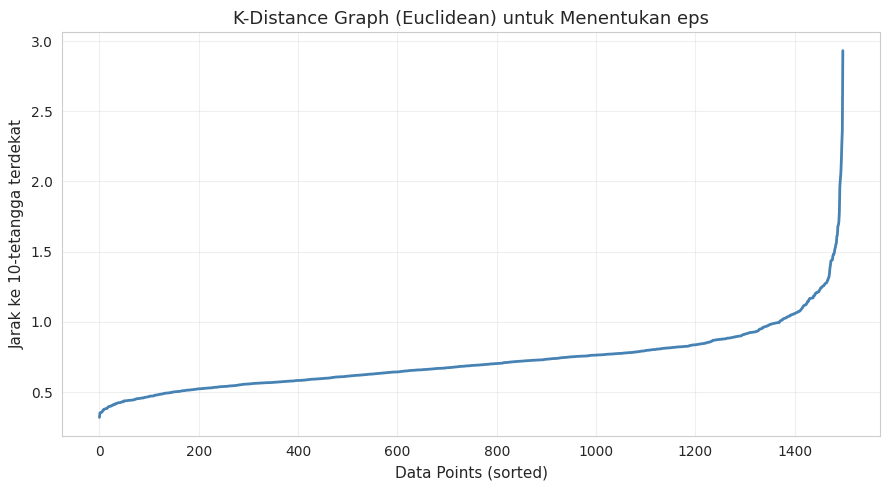


Kandidat eps berdasarkan persentil:
  Persentil 85: 0.8875
  Persentil 90: 0.9747
  Persentil 92: 1.0209
  Persentil 95: 1.1219
  Persentil 97: 1.2401


In [ ]:
# Tentukan min_samples (rule of thumb: 2 * jumlah fitur)
MIN_SAMPLES = 2 * len(FEATURES)
print(f"min_samples = {MIN_SAMPLES}")

# Hitung jarak ke k-tetangga terdekat (Euclidean)
neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES, metric='euclidean')
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)

# Ambil jarak ke tetangga terjauh, sort ascending
distances = np.sort(distances[:, -1])

# Plot k-distance graph
plt.figure(figsize=(9, 5))
plt.plot(distances, color='steelblue', linewidth=2)
plt.xlabel(f'Data Points (sorted)', fontsize=11)
plt.ylabel(f'Jarak ke {MIN_SAMPLES}-tetangga terdekat', fontsize=11)
plt.title('K-Distance Graph (Euclidean) untuk Menentukan eps', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tampilkan kandidat eps di sekitar "siku"
print("\nKandidat eps berdasarkan persentil:")
for p in [85, 90, 92, 95, 97]:
    print(f"  Persentil {p}: {np.percentile(distances, p):.4f}")

In [ ]:
# ============================================
# PARAMETER DBSCAN (sesuaikan EPS_VALUE dari Cell 4)
# ============================================
EPS_VALUE = 0.5   # <-- ubah sesuai hasil k-distance graph
MIN_SAMPLES = 2 * len(FEATURES)

# Mulai tracking
tracemalloc.start()
start_time = time.time()

# Training
dbscan = DBSCAN(eps=EPS_VALUE, min_samples=MIN_SAMPLES, metric='euclidean')
labels = dbscan.fit_predict(X_scaled)

# Stop tracking
exec_time = time.time() - start_time
_, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Simpan hasil
df['cluster'] = labels

# Ringkasan
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("="*55)
print("HASIL DBSCAN (EUCLIDEAN)")
print("="*55)
print(f"eps                  : {EPS_VALUE}")
print(f"min_samples          : {MIN_SAMPLES}")
print(f"Jumlah cluster       : {n_clusters}")
print(f"Jumlah noise/outlier : {n_noise} ({n_noise/len(df)*100:.2f}%)")
print(f"Waktu eksekusi       : {exec_time:.4f} detik")
print(f"Peak memory          : {peak/1024:.2f} KB")
print("\nDistribusi cluster:")
print(df['cluster'].value_counts().sort_index())

HASIL DBSCAN (EUCLIDEAN)
eps                  : 0.5
min_samples          : 10
Jumlah cluster       : 17
Jumlah noise/outlier : 1095 (73.10%)
Waktu eksekusi       : 0.0288 detik
Peak memory          : 380.33 KB

Distribusi cluster:
cluster
-1     1095
 0       17
 1      200
 2       16
 3       10
 4       13
 5       13
 6       15
 7       27
 8        9
 9       10
 10      10
 11      10
 12      10
 13      10
 14      13
 15      10
 16      10
Name: count, dtype: int64


In [ ]:
# Rata-rata fitur per cluster (exclude noise)
cluster_only = df[df['cluster'] != -1]
print("Rata-rata fitur per cluster (tanpa noise):")
print(cluster_only.groupby('cluster')[FEATURES].mean().round(2))

Rata-rata fitur per cluster (tanpa noise):
         luas_m2  jumlah_kamar  jumlah_kamar_mandi  usia_bangunan  \
cluster                                                             
0         106.49           5.0                 4.0          24.06   
1          96.80           1.0                 1.0          21.33   
2         108.14           2.0                 1.0          30.50   
3         156.28           2.0                 1.0          16.50   
4         156.45           2.0                 2.0          18.00   
5          56.23           2.0                 2.0           9.00   
6          89.65           2.0                 2.0          33.93   
7          42.44           2.0                 1.0          27.74   
8          59.83           2.0                 2.0          26.00   
9         112.92           3.0                 3.0           7.20   
10         82.32           2.0                 2.0           2.20   
11         32.45           4.0                 4.0          

In [ ]:
# Distribusi lokasi & kategori harga per cluster
print("\nDistribusi lokasi per cluster:")
print(pd.crosstab(df['cluster'], df['lokasi']))

print("\nDistribusi kategori harga per cluster:")
print(pd.crosstab(df['cluster'], df['kategori_harga']))


Distribusi lokasi per cluster:
lokasi   Bekasi  Bogor  Depok  Jakarta Selatan  Jakarta Utara  Tangerang
cluster                                                                 
-1          178    181    162              207            192        175
 0            5      3      3                0              1          5
 1           43     44     43                9             29         32
 2            1      1      5                0              2          7
 3            8      1      0                0              0          1
 4            1      1      4                0              1          6
 5            2      1      1                2              5          2
 6            4      2      1                3              2          3
 7            3     10      2                2              5          5
 8            1      3      2                0              2          1
 9            3      2      4                0              0          1
 10           0    

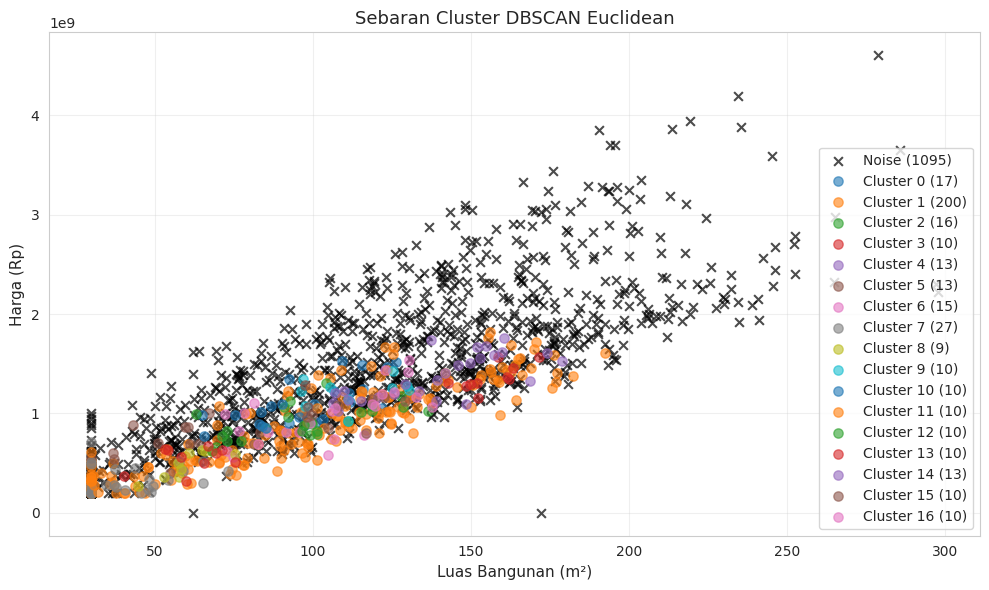

In [ ]:
plt.figure(figsize=(10, 6))

# Plot per cluster
for label in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == label]
    if label == -1:
        plt.scatter(subset['luas_m2'], subset['harga'],
                    c='black', marker='x', s=40, alpha=0.7,
                    label=f'Noise ({len(subset)})')
    else:
        plt.scatter(subset['luas_m2'], subset['harga'],
                    s=45, alpha=0.6, label=f'Cluster {label} ({len(subset)})')

plt.xlabel('Luas Bangunan (m²)', fontsize=11)
plt.ylabel('Harga (Rp)', fontsize=11)
plt.title('Sebaran Cluster DBSCAN Euclidean', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

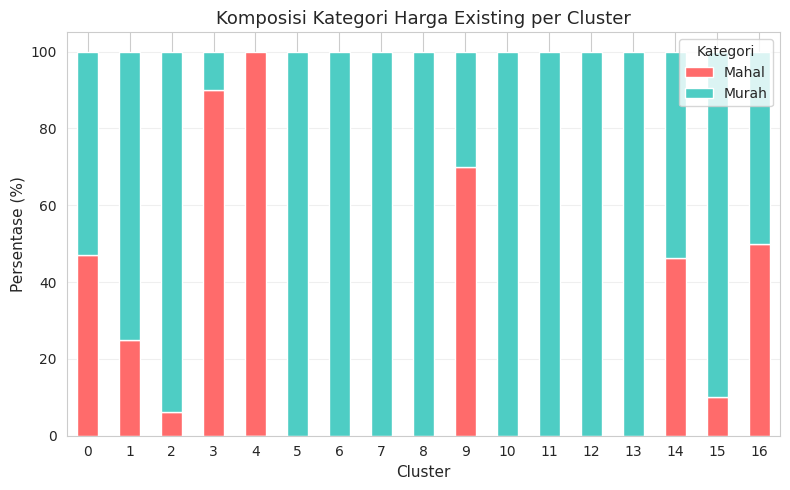


Persentase kategori harga per cluster (%):
kategori_harga   Mahal   Murah
cluster                       
0                47.06   52.94
1                25.00   75.00
2                 6.25   93.75
3                90.00   10.00
4               100.00    0.00
5                 0.00  100.00
6                 0.00  100.00
7                 0.00  100.00
8                 0.00  100.00
9                70.00   30.00
10                0.00  100.00
11                0.00  100.00
12                0.00  100.00
13                0.00  100.00
14               46.15   53.85
15               10.00   90.00
16               50.00   50.00


In [ ]:
# Crosstab persentase (exclude noise)
comp = pd.crosstab(cluster_only['cluster'],
                   cluster_only['kategori_harga'],
                   normalize='index') * 100

comp.plot(kind='bar', stacked=True, figsize=(8, 5),
          color=['#FF6B6B', '#4ECDC4'], edgecolor='white')
plt.xlabel('Cluster', fontsize=11)
plt.ylabel('Persentase (%)', fontsize=11)
plt.title('Komposisi Kategori Harga Existing per Cluster', fontsize=13)
plt.legend(title='Kategori', loc='upper right')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nPersentase kategori harga per cluster (%):")
print(comp.round(2))

In [ ]:
# Silhouette hanya dihitung pada data non-noise
mask = df['cluster'] != -1

if len(set(df.loc[mask, 'cluster'])) > 1:
    sil_score = silhouette_score(X_scaled[mask],
                                  df.loc[mask, 'cluster'],
                                  metric='euclidean')
    print(f"Silhouette Score (Euclidean): {sil_score:.4f}")
else:
    sil_score = None
    print("Silhouette tidak dapat dihitung (cluster < 2)")

Silhouette Score (Euclidean): 0.0679


In [ ]:
# Dictionary metrik — format ini akan dipakai di semua notebook
hasil_dbscan_euclidean = {
    'Metode'              : 'DBSCAN',
    'Distance Metric'     : 'Euclidean',
    'Jumlah Cluster'      : n_clusters,
    'Jumlah Noise'        : n_noise,
    'Waktu Eksekusi (s)'  : round(exec_time, 4),
    'Peak Memory (KB)'    : round(peak / 1024, 2),
    'Silhouette Score'    : round(sil_score, 4) if sil_score else None,
    'Parameter'           : f'eps={EPS_VALUE}, min_samples={MIN_SAMPLES}'
}

# Tampilkan sebagai tabel
tabel = pd.DataFrame([hasil_dbscan_euclidean])
print("="*60)
print("RINGKASAN METRIK — DBSCAN EUCLIDEAN")
print("="*60)
tabel.T

RINGKASAN METRIK — DBSCAN EUCLIDEAN


,0
Metode,DBSCAN
Distance Metric,Euclidean
Jumlah Cluster,17
Jumlah Noise,1095
Waktu Eksekusi (s),0.0288
Peak Memory (KB),380.33
Silhouette Score,0.0679
Parameter,"eps=0.5, min_samples=10"
